In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np

In [2]:
df =pd.read_csv(r"C:\Users\DELL\Downloads\Day 68 country_wise_latest.csv")
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [3]:
print(df.isnull().sum())
print(df.shape)
print(df.columns)
print(df.describe)

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64
(187, 15)
Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')
<bound method NDFrame.describe of          Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0           Afghanistan      36263    1269      25198    9796        106   
1               Albania       4880     144       2745    

In [4]:
total_countries=df["Country/Region"].nunique()
print("total Countries:",total_countries)

total Countries: 187


In [5]:
total_confirmed =df["Confirmed"].sum()
print("total confirmed case :", total_confirmed)

total confirmed case : 16480485


In [6]:
total_death =df["Deaths"].sum()
print("total death case:",total_death)

total death case: 654036


In [7]:
total_recovered =df["Recovered"].sum()
print("total recovered case :", total_recovered)

total recovered case : 9468087


In [8]:
total_active=df["Active"].sum()
print("total active case :", total_active)

total active case : 6358362


In [9]:
glopal_recovery_rate=(total_recovered/total_confirmed)*100
print("glopal recovery rate: {:.2f}%".format(glopal_recovery_rate))

glopal recovery rate: 57.45%


In [10]:
glopal_mortality_rate=(total_death/total_confirmed)*100
print("glopal mortality rate: {:.2f}%".format(glopal_mortality_rate))

glopal mortality rate: 3.97%


In [11]:
total_region=df["WHO Region"].nunique()
print("Total WHO region:",total_region)

Total WHO region: 6


In [13]:
most_affected_country =df.loc[df["Confirmed"].idxmax(),"Country/Region"]
print("most affected country(by confirmed cases):",most_affected_country)

most affected country(by confirmed cases): US


In [14]:
df["Recovery Rate"]= (df["Recovered"]/df["Confirmed"])*100
df["Recovery Rate"].replace([float("inf"),-float("inf")],0,inplace=True)
df["Recovery Rate"].fillna(0,inplace=True)

highest_recovery_rate =df.loc[df["Recovery Rate"].idxmax(),"Country/Region"]
print("Country with Highest Recovery Rate:",highest_recovery_rate)

Country with Highest Recovery Rate: Dominica


C:\Users\DELL\AppData\Local\Temp\ipykernel_11232\3646002610.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Recovery Rate"].replace([float("inf"),-float("inf")],0,inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11232\3646002610.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

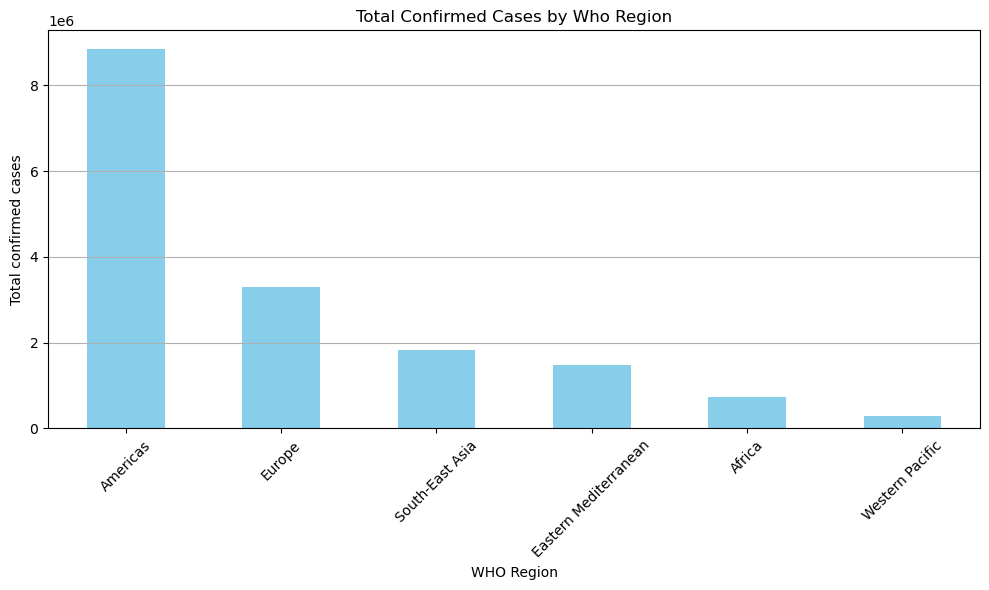

In [16]:
region_confirmed = df.groupby('WHO Region')['Confirmed'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
region_confirmed.plot(kind='bar',color ='skyblue')
plt.title('Total Confirmed Cases by Who Region')
plt.xlabel('WHO Region')
plt.ylabel('Total confirmed cases')
plt.xticks(rotation =45)
plt.grid(axis='y')
plt.tight_layout()
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11232\2852847860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country/Region',y='Active',data=top10_active, palette='Reds_r')


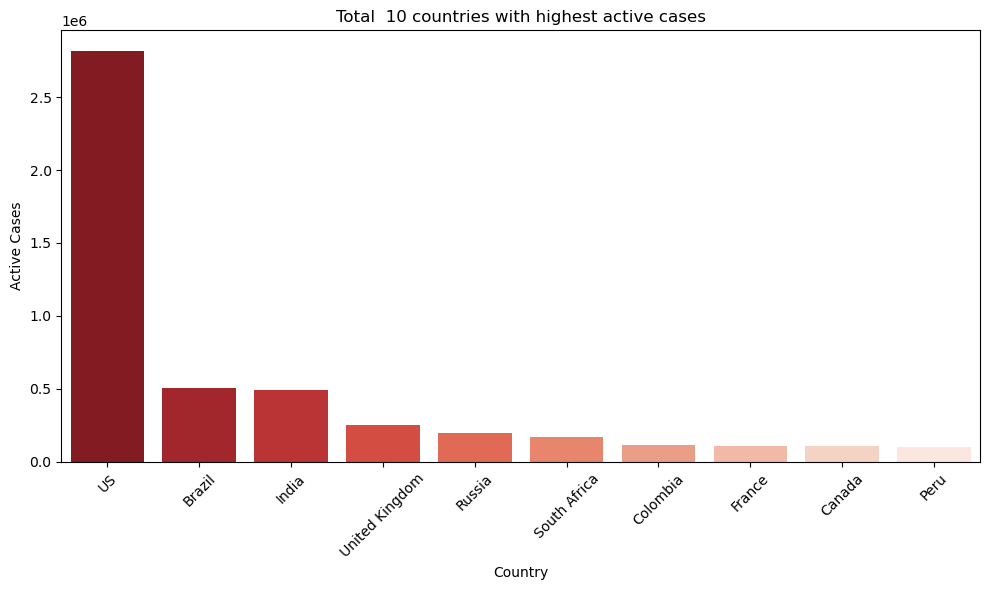

In [17]:
top10_active=df.sort_values(by='Active',ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Country/Region',y='Active',data=top10_active, palette='Reds_r')
plt.title('Total  10 countries with highest active cases')
plt.xlabel('Country')
plt.ylabel('Active Cases')
plt.xticks(rotation =45)
plt.tight_layout()
plt.show()

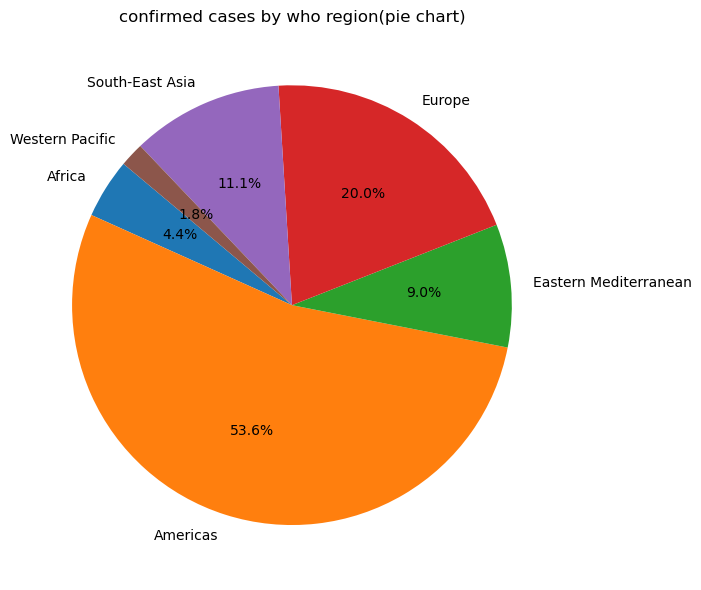

In [18]:
region_cases=df.groupby('WHO Region')['Confirmed'].sum()

plt.figure(figsize=(8,6))
plt.pie(region_cases,labels=region_cases.index,autopct='%1.1f%%', startangle=140)
plt.title('confirmed cases by who region(pie chart)')
plt.tight_layout()
plt.show()

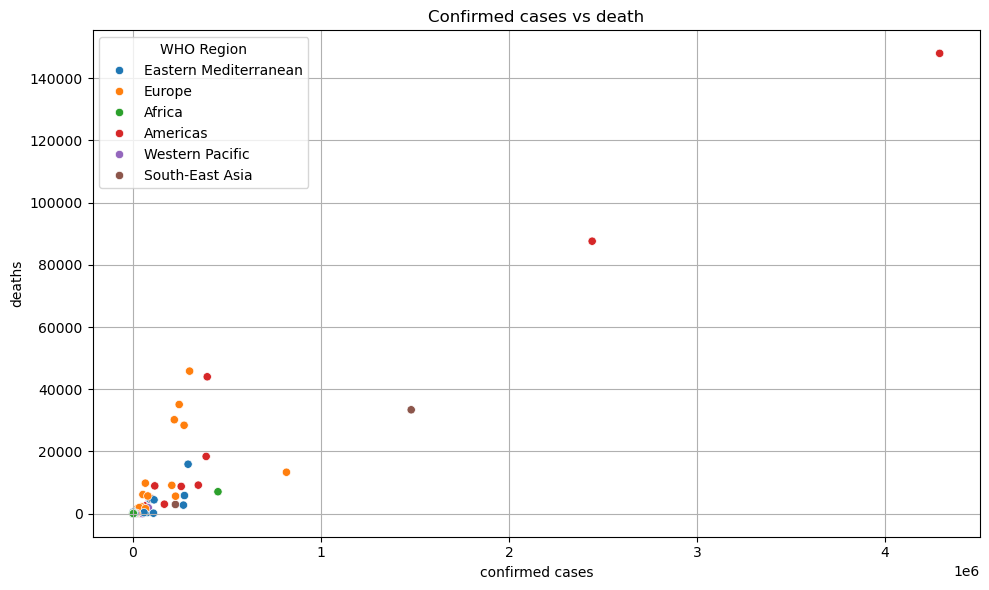

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Confirmed', y='Deaths', hue= 'WHO Region',data=df)
plt.title('Confirmed cases vs death')
plt.xlabel('confirmed cases')
plt.ylabel('deaths')
plt.grid(True)
plt.tight_layout()
plt.tight_layout()
plt.show()

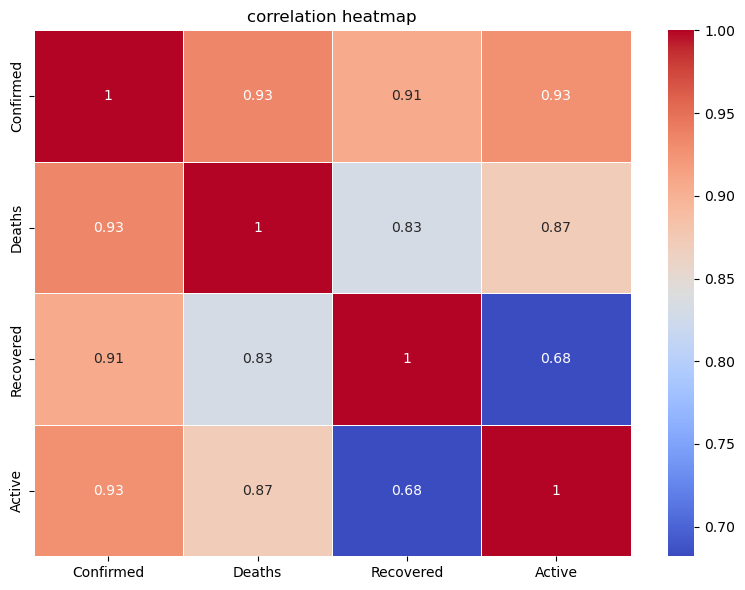

In [20]:
corelation= df[['Confirmed','Deaths','Recovered','Active']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corelation,annot=True,cmap='coolwarm',linewidth=0.5)
plt.title('correlation heatmap')
plt.tight_layout()
plt.show()


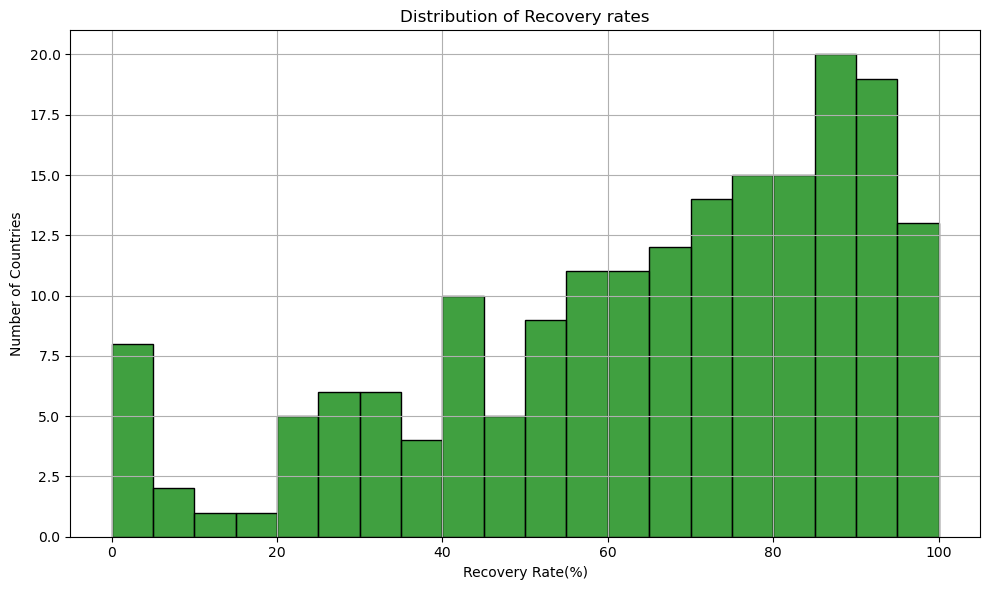

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df['Recovery Rate'],bins=20,color='green')
plt.title('Distribution of Recovery rates')
plt.xlabel('Recovery Rate(%)')
plt.ylabel('Number of Countries')
plt.grid(True)
plt.tight_layout()
plt.tight_layout()
plt.show()

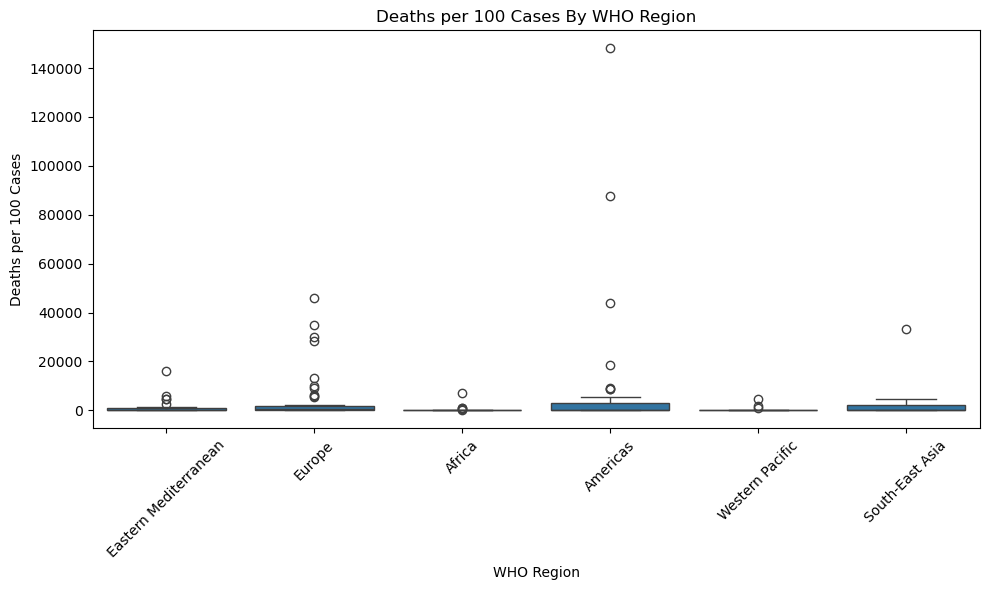

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x='WHO Region', y='Deaths',data=df)
plt.title('Deaths per 100 Cases By WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Deaths per 100 Cases')
plt.xticks(rotation =45)

plt.tight_layout()
plt.show()

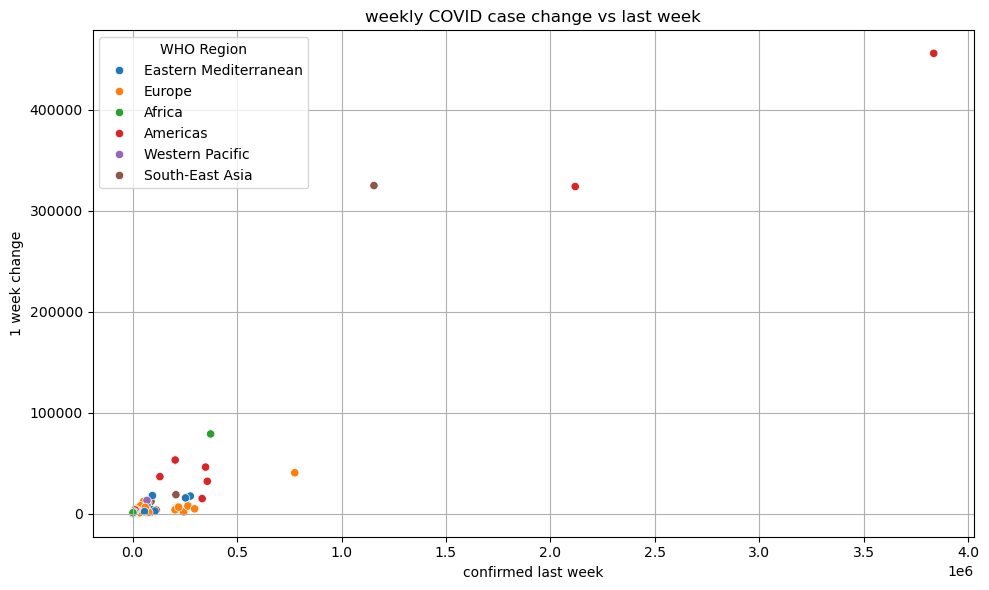

In [23]:
if 'Confirmed last week' in df.columns and '1 week change' in df.columns:
  plt.figure(figsize=(10,6))
  sns.scatterplot(data=df, x='Confirmed last week', y='1 week change', hue='WHO Region')
  plt.title('weekly COVID case change vs last week')
  plt.xlabel('confirmed last week')
  plt.ylabel('1 week change')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

else:

  print("Required columns not found: 'Confirmed last week'& '1 week change'")

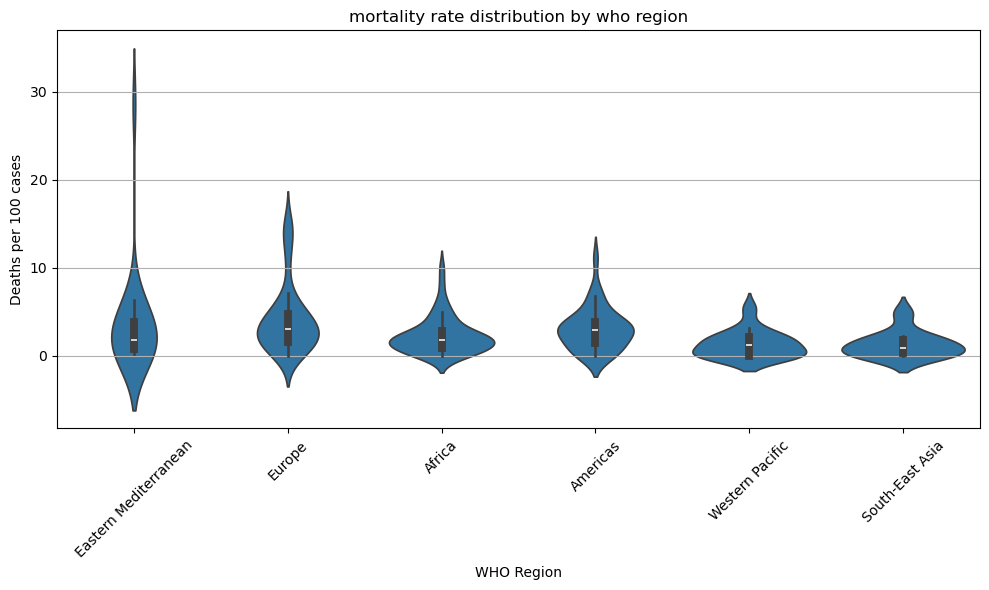

In [24]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df,x='WHO Region',y='Deaths / 100 Cases')
plt.title('mortality rate distribution by who region')
plt.xlabel('WHO Region')
plt.ylabel('Deaths per 100 cases')
plt.xticks(rotation =45)
plt.grid(axis='y')
plt.tight_layout()
plt.tight_layout()
plt.show()


ERROR: Could not find a version that satisfies the requirement dash (from versions: none)
ERROR: No matching distribution found for dash


3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [33]:

!pip install streamlit

In [34]:
import streamlit as st

D:\new\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


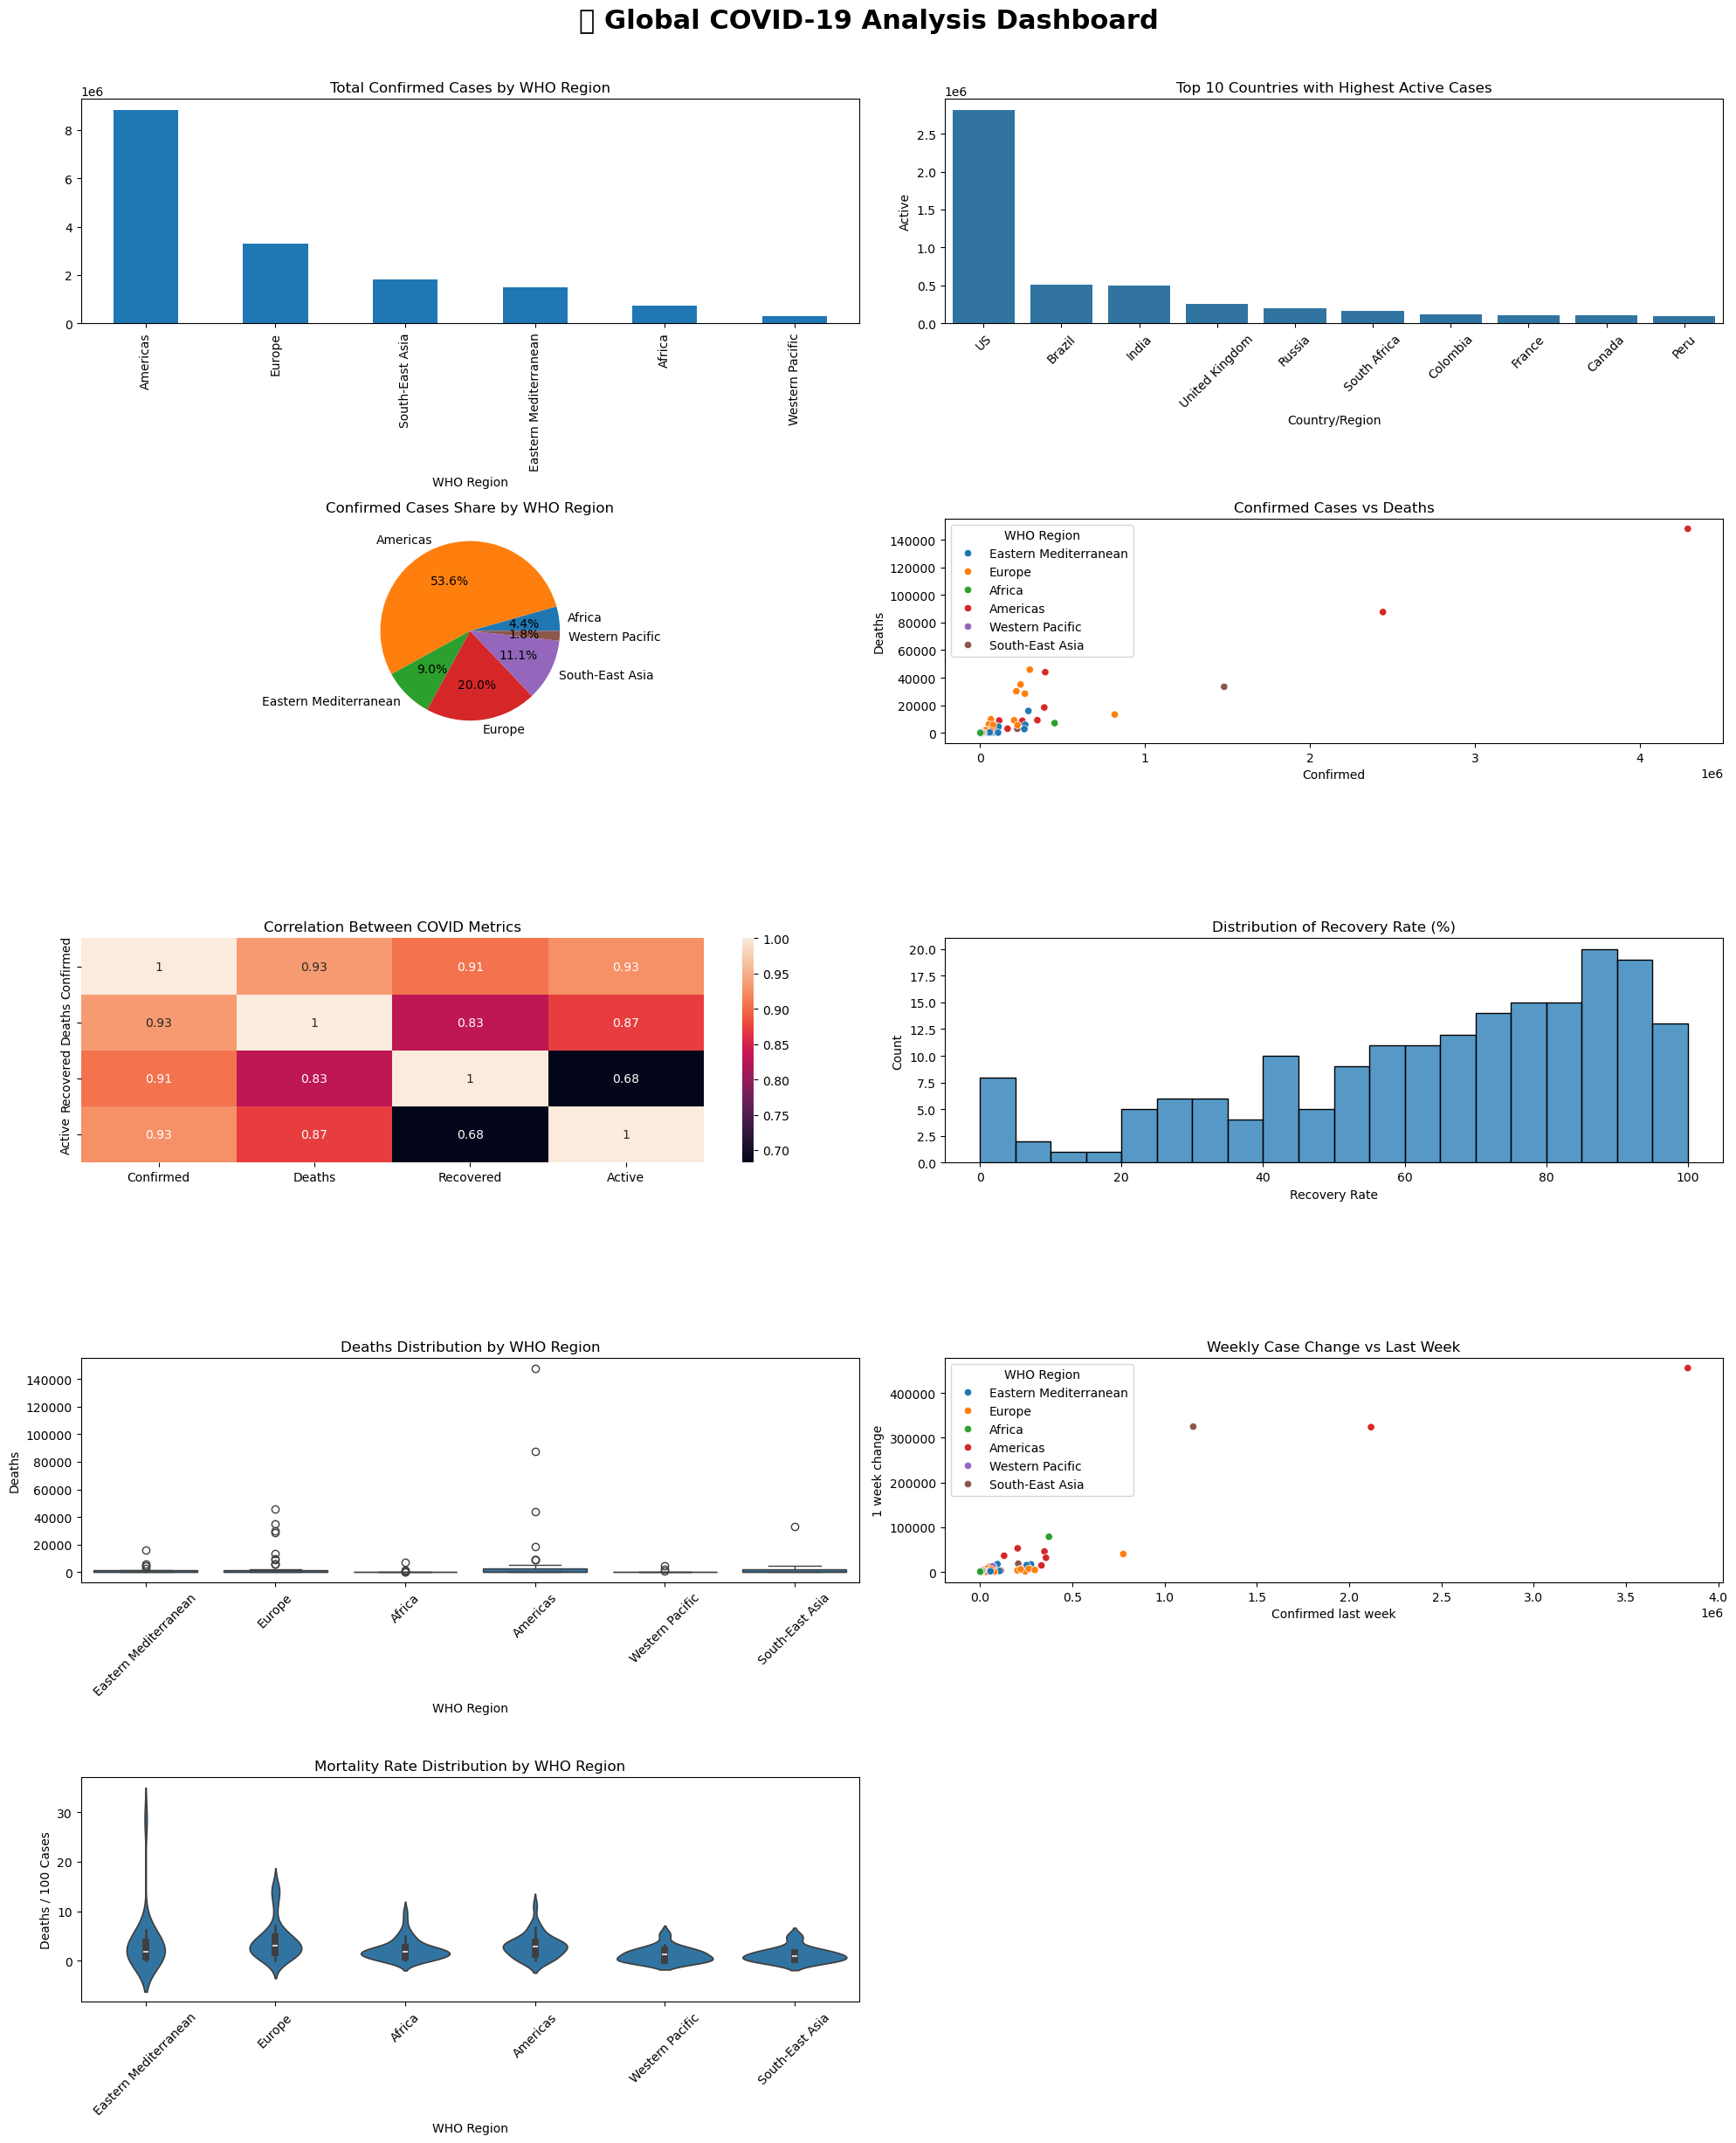